# Image Classification
- VGG16 활용하여 캐글 개&고양이 분류 데이터 활용


In [1]:
# 필요한 라이브러리 불러오기
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

path_to_zip = tf.keras.utils.get_file('cats_and_dogs.zip', origin=_URL, extract=True)

path = os.path.join(os.path.dirname(path_to_zip), 'cats_and_dogs_filtered')

68616192/68606236 [==============================] - 0s 0us/step


In [3]:
train_dir = os.path.join(path, 'train')
validation_dir = os.path.join(path, 'validation')
print(train_dir)
print(validation_dir)

/aiffel/.keras/datasets/cats_and_dogs_filtered/train
/aiffel/.keras/datasets/cats_and_dogs_filtered/validation


In [4]:
# directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'cats') 
print(train_cats_dir)

# directory with our training dog pictures 
train_dogs_dir = os.path.join(train_dir, 'dogs')  
print(train_dogs_dir)

# directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')  
print(validation_cats_dir)

# directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')  
print(validation_dogs_dir)

/aiffel/.keras/datasets/cats_and_dogs_filtered/train/cats
/aiffel/.keras/datasets/cats_and_dogs_filtered/train/dogs
/aiffel/.keras/datasets/cats_and_dogs_filtered/validation/cats
/aiffel/.keras/datasets/cats_and_dogs_filtered/validation/dogs


In [5]:
num_cats_tr = len(os.listdir(train_cats_dir))
print('total training cat images:', num_cats_tr)
num_dogs_tr = len(os.listdir(train_dogs_dir))
print('total training dog images:', num_dogs_tr)

print("--")

num_cats_val = len(os.listdir(validation_cats_dir))
print('total validation cat images:', num_cats_val)
num_dogs_val = len(os.listdir(validation_dogs_dir))
print('total validation dog images:', num_dogs_val)

print("--")

total_train = num_cats_tr + num_dogs_tr
print("Total training images:", total_train)
total_val = num_cats_val + num_dogs_val
print("Total validation images:", total_val)

total training cat images: 1000
total training dog images: 1000
--
total validation cat images: 500
total validation dog images: 500
--
Total training images: 2000
Total validation images: 1000


In [6]:
# parameter Initialization
batch_size = 16
epochs = 5
IMG_HEIGHT = 256
IMG_WIDTH = 256

In [7]:
# 데이터를 시각화하기 위한 함수
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(10,10))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
# train 데이터가 2000장밖에 안되어 data augmentation 으로 데이터 수 늘리기

# Training data generator
image_gen_train = ImageDataGenerator(rescale=1./255,
                                     rotation_range=0.3,
                                     width_shift_range=0.1,
                                     height_shift_range=0.1,
                                     zoom_range=0.2,
                                     horizontal_flip=True, 
                                     vertical_flip=False)

In [9]:
train_data_gen = image_gen_train.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     shuffle=True,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')


Found 2000 images belonging to 2 classes.


In [10]:
train_data_gen[0][0].shape

(16, 256, 256, 3)

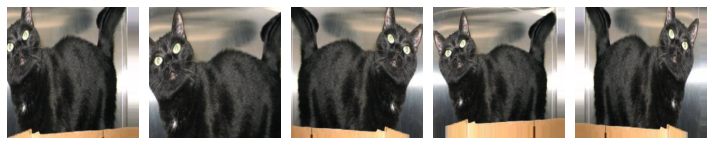

In [11]:
augmented_images = [train_data_gen[0][0][0] for i in range(5)]
plotImages(augmented_images)

In [12]:
# Validation data generator
image_gen_val = ImageDataGenerator(rescale=1./255)

In [13]:
val_data_gen = image_gen_val.flow_from_directory(batch_size=batch_size,
                                                 directory=validation_dir,
                                                 target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                 class_mode='binary')

Found 1000 images belonging to 2 classes.


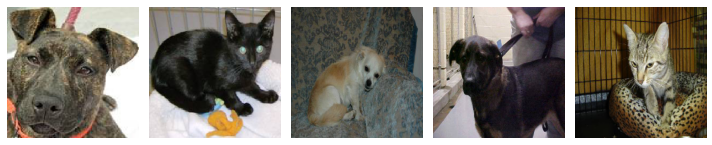

In [14]:
# validation 데이터 확인
sample_training_images, _ = next(val_data_gen)
plotImages(sample_training_images[:5])

In [15]:
_[:5] # 정답 데이터

array([1., 0., 1., 1., 0.], dtype=float32)

# 문제 1-1. VGG16 모델 구현하기

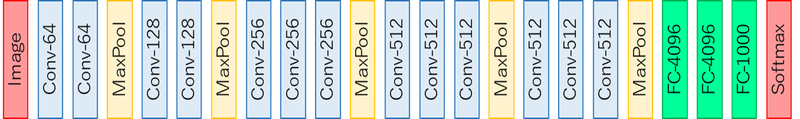

In [16]:
# 문제1-1. 이미지에 나온 VGG16 모델을 구현하세요.

# 메모리 줄이기 위한 조치 추가
from tensorflow.keras.mixed_precision import set_global_policy

# Mixed Precision Training 설정
set_global_policy('mixed_float16')

# 입력 레이어 정의
input_layer = tf.keras.layers.Input(shape=(256, 256, 3))

# Conv Block 1
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

# Conv Block 2
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

# Conv Block 3
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

# Conv Block 4
x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPool2D((2, 2))(x)

# # Conv Block 5
# x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
# x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
# x = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
# x = tf.keras.layers.MaxPool2D((2, 2))(x)

# Fully Connected Layers
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
out_layer = tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')(x)

# 모델 정의
model = tf.keras.Model(inputs=[input_layer], outputs=[out_layer])

# 모델 요약 출력
model.summary()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: Tesla T4, compute capability 7.5
Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 256, 256, 3)]     0         
_________________________________________________________________
conv2d (Conv2D)              (None, 256, 256, 32)      896       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 256, 256, 32)      9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 128, 128, 32)      0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 128, 128, 64)      18496     
_________________________________

In [17]:
# 손실함수, OPTIMIZER, METRIC 설정

loss_function=tf.keras.losses.binary_crossentropy
optimize=tf.keras.optimizers.Adam(learning_rate=0.01)
metric=tf.keras.metrics.binary_accuracy
model.compile(loss=loss_function,
              optimizer=optimize,
              metrics=[metric])

# callbacks_list= [tf.keras.callbacks.TensorBoard(log_dir='log_dir', histogram_freq=1)]
# callback 함수를 활용하고 싶다면 추가해서 학습하는 데에 활용해 보세요.

In [18]:
history = model.fit(
      train_data_gen,
      steps_per_epoch=(len(os.listdir(train_cats_dir)) + len(os.listdir(train_dogs_dir)))/batch_size,
      epochs=epochs,
      validation_data=val_data_gen,
      # callbacks=callbacks_list,
      validation_freq=1)

Epoch 1/5


KeyboardInterrupt: 

In [ ]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.plot(epochs_range, acc, 'bo', label='Training acc')
plt.plot(epochs_range, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [34]:
!nvidia-smi

Tue Aug 13 09:11:09 2024       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.256.02   Driver Version: 470.256.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   55C    P0    29W /  70W |   2250MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [24]:
tf.keras.backend.clear_session()

# 문제 1-2. 다양한 방법을 사용하여 모델 성능 올리기

In [25]:
# 문제 1-2. hyperparameter 설정
batch_size = 16  # 더 큰 배치 크기를 사용하여 더 많은 데이터를 한 번에 학습시킴
epochs = 10  # 에포크 수를 늘려서 더 많은 학습 기회를 제공
learning_rate = 0.001  # 학습률을 조정하여 너무 크거나 작지 않게 설정
IMG_HEIGHT = 256
IMG_WIDTH = 256

In [26]:
# 문제 1-2. 데이터 generator 생성
# Training data generator with more augmentation
image_gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=0.4,  # 회전 범위를 넓혀 더 다양한 이미지를 생성
    width_shift_range=0.3,  # 수평 이동 범위를 넓힘
    height_shift_range=0.3,  # 수직 이동 범위를 넓힘
    shear_range=0.3,  # 밀림 정도 조정
    zoom_range=0.3,  # 줌 조정
    horizontal_flip=True,  # 수평 반전 사용
    vertical_flip=True,
    fill_mode='nearest'  # 빈 공간을 채우기 위한 방법
)

train_data_gen = image_gen_train.flow_from_directory(
    batch_size=batch_size,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

# Validation data generator
image_gen_val = ImageDataGenerator(rescale=1./255)

val_data_gen = image_gen_val.flow_from_directory(
    batch_size=batch_size,
    directory=validation_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [27]:
# 문제 1-2. 모델 구현
from tensorflow.keras import layers

input_layer = tf.keras.layers.Input(shape=(256, 256, 3))

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_layer)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)  # 드롭아웃 추가

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)  # 드롭아웃 추가

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)  # 드롭아웃 추가

x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)  # 드롭아웃 추가

x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)  # 드롭아웃 추가

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)  # 드롭아웃 추가
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)  # 드롭아웃 추가
out_layer = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

model = tf.keras.Model(inputs=[input_layer], outputs=[out_layer])

In [28]:
# 문제 1-2. loss function, optimizer, metric 설정 및 모델 컴파일
# 개선된 손실 함수, 옵티마이저, 메트릭 설정 및 모델 컴파일
loss_function = tf.keras.losses.binary_crossentropy
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
metrics = [tf.keras.metrics.BinaryAccuracy(), 
           tf.keras.metrics.AUC()]  # 추가적인 메트릭 사용

model.compile(
    loss=loss_function,
    optimizer=optimizer,
    metrics=metrics
)

# 모델 훈련
history = model.fit(
      train_data_gen,
      steps_per_epoch=(len(os.listdir(train_cats_dir)) + len(os.listdir(train_dogs_dir))) // batch_size,
      epochs=epochs,
      validation_data=val_data_gen,
      validation_freq=1
)

Epoch 1/10
125/125 [==============================] - 37s 282ms/step - loss: 0.6993 - binary_accuracy: 0.5010 - auc: 0.4881 - val_loss: 0.6932 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 2/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6934 - binary_accuracy: 0.4955 - auc: 0.4873 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 3/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6934 - binary_accuracy: 0.4875 - auc: 0.4955 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 4/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6937 - binary_accuracy: 0.4930 - auc: 0.4863 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 5/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6940 - binary_accuracy: 0.4830 - auc: 0.4728 - val_loss: 0.6932 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 6/10
125/125 [=========================

In [29]:
# 모델 학습 - 콜백 추가

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)


history = model.fit(
      train_data_gen,
      steps_per_epoch=(len(os.listdir(train_cats_dir)) + len(os.listdir(train_dogs_dir)))/batch_size,
      epochs=epochs,
      validation_data=val_data_gen,
       callbacks=[early_stopping, model_checkpoint],
      validation_freq=1)

Epoch 1/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6934 - binary_accuracy: 0.5005 - auc: 0.4932 - val_loss: 0.6932 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 2/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6935 - binary_accuracy: 0.4930 - auc: 0.4819 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 3/10
125/125 [==============================] - 34s 275ms/step - loss: 0.6933 - binary_accuracy: 0.4950 - auc: 0.4947 - val_loss: 0.6932 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 4/10
125/125 [==============================] - 34s 273ms/step - loss: 0.6935 - binary_accuracy: 0.5000 - auc: 0.4822 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 5/10
125/125 [==============================] - 34s 272ms/step - loss: 0.6934 - binary_accuracy: 0.4860 - auc: 0.4905 - val_loss: 0.6931 - val_binary_accuracy: 0.5000 - val_auc: 0.5000
Epoch 6/10
125/125 [=========================

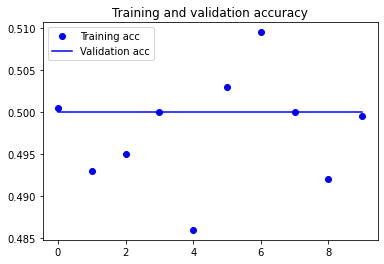

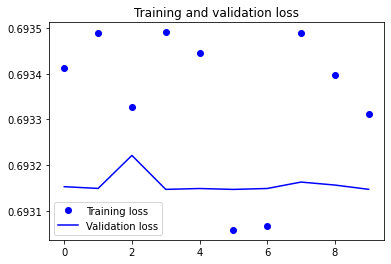

In [30]:
acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.plot(epochs_range, acc, 'bo', label='Training acc')
plt.plot(epochs_range, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs_range, loss, 'bo', label='Training loss')
plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

# Transfer Learning 해보기

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

# VGG16 모델을 사용하여 전이 학습 수행
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# 기존의 사전 학습된 레이어를 고정
for layer in base_model.layers:
    layer.trainable = False

# 추가적인 레이어를 연결
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 모델 컴파일
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['binary_accuracy', 'AUC']
)

# 모델 훈련
history = model.fit(
    train_data_gen,
    steps_per_epoch=len(train_data_gen),
    epochs=epochs,
    validation_data=val_data_gen,
    validation_steps=len(val_data_gen),
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/10
125/125 [==============================] - 36s 281ms/step - loss: 0.6839 - binary_accuracy: 0.6205 - auc: 0.6622 - val_loss: 0.4583 - val_binary_accuracy: 0.7740 - val_auc: 0.9228
Epoch 2/10
125/125 [==============================] - 34s 272ms/step - loss: 0.5579 - binary_accuracy: 0.7050 - auc: 0.7815 - val_loss: 0.4113 - val_binary_accuracy: 0.8080 - val_auc: 0.9332
Epoch 3/10
125/125 [==============================] - 35s 276ms/step - loss: 0.5187 - binary_accuracy: 0.7445 - auc: 0.8231 - val_loss: 0.3456 - val_binary_accuracy: 0.8550 - val_auc: 0.9410
Epoch 4/10
125/125 [==============================] - 34s 271ms/step - loss: 0.4839 - binary_accuracy: 0.7655 - auc: 0.8443 - val_loss: 0.3216 - val_binary_accuracy: 0.8580 - val_auc: 0.9581
Epoch 5/10
125/125 [==============================] - 34s 272ms/step - loss: 0.4820 - binary_accuracy: 0.7740 - auc: 0.8497 - val_loss: 0.2904 - val_binary_accuracy: 0.8810 - val_auc: 0.9586
Epoch 6/10
125/125 [=========================